In [ ]:
!pip install ultralytics

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CTyLaUYgvqEmaBiPpbEC")
project = rf.workspace("mohameds-workspace-wtvgk").project("mask-wearing-iskms-syqvf")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
dataset_dir = dataset.location

print(dataset_dir)

/content/Mask-Wearing-1


In [ ]:
yaml_path = "/content/Mask-Wearing-1/data.yaml"

with open(yaml_path,"r") as f:
  print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Mask', 'NO-Mask']

roboflow:
  workspace: mohameds-workspace-wtvgk
  project: mask-wearing-iskms-syqvf
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mohameds-workspace-wtvgk/mask-wearing-iskms-syqvf/dataset/1


In [ ]:
import torch

device = ("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")


results = model.train(
    data = yaml_path,
    epochs = 30,
    imgsz = 640,
    batch=16,
    device = device,
    name="ppe_yolo11_run"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mask-Wearing-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_yolo11_run, nbs=64, nms=

In [ ]:
metric = model.val()

print(metric.box.map50)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1395.6±999.9 MB/s, size: 99.7 KB)
val: Scanning /content/Mask-Wearing-1/valid/labels.cache... 706 images, 124 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 706/706 134.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 2.6it/s 17.3s
                   all        706       1059      0.936      0.892       0.95      0.707
                  Mask        292        554      0.931      0.908      0.951       0.72
               NO-Mask        327        505      0.941      0.877      0.948      0.694
Speed: 2.7ms preprocess, 7.4ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val
0.9496553508616918



image 1/353 /content/Mask-Wearing-1/test/images/-1x-1_jpg.rf.f96271a903701002f9727c74f50a4ec4.jpg: 448x640 11 Masks, 3 NO-Masks, 14.5ms
image 2/353 /content/Mask-Wearing-1/test/images/002_1024_jpeg_jpg.rf.98086bb2713e9a5558cafb70ae2509ab.jpg: 384x640 3 Masks, 13.1ms
image 3/353 /content/Mask-Wearing-1/test/images/0109-00176-096b1_jpg.rf.e0bbfc0ad969217c4daf347b753b2561.jpg: 640x416 1 Mask, 12.7ms
image 4/353 /content/Mask-Wearing-1/test/images/0209-00176-076b1_jpg.rf.3da8ebb0f346e07ef26f13b2eebeff6f.jpg: 448x640 5 Masks, 1 NO-Mask, 12.8ms
image 5/353 /content/Mask-Wearing-1/test/images/0_10725_jpg.rf.de2b0054c96e675ec8181d7d40069a2f.jpg: 448x640 2 Masks, 2 NO-Masks, 16.5ms
image 6/353 /content/Mask-Wearing-1/test/images/0_8w7mkX-PHcfMM5s6_jpeg_jpg.rf.8bba745df263c74d3986ffe1b63f3a48.jpg: 448x640 109 Masks, 18 NO-Masks, 15.9ms
image 7/353 /content/Mask-Wearing-1/test/images/0_Concern-In-China-As-Mystery-Virus-Spreads_jpg.rf.ce5044e35cb7f43e2edc38800e13ea41.jpg: 352x640 3 Masks, 21.8ms


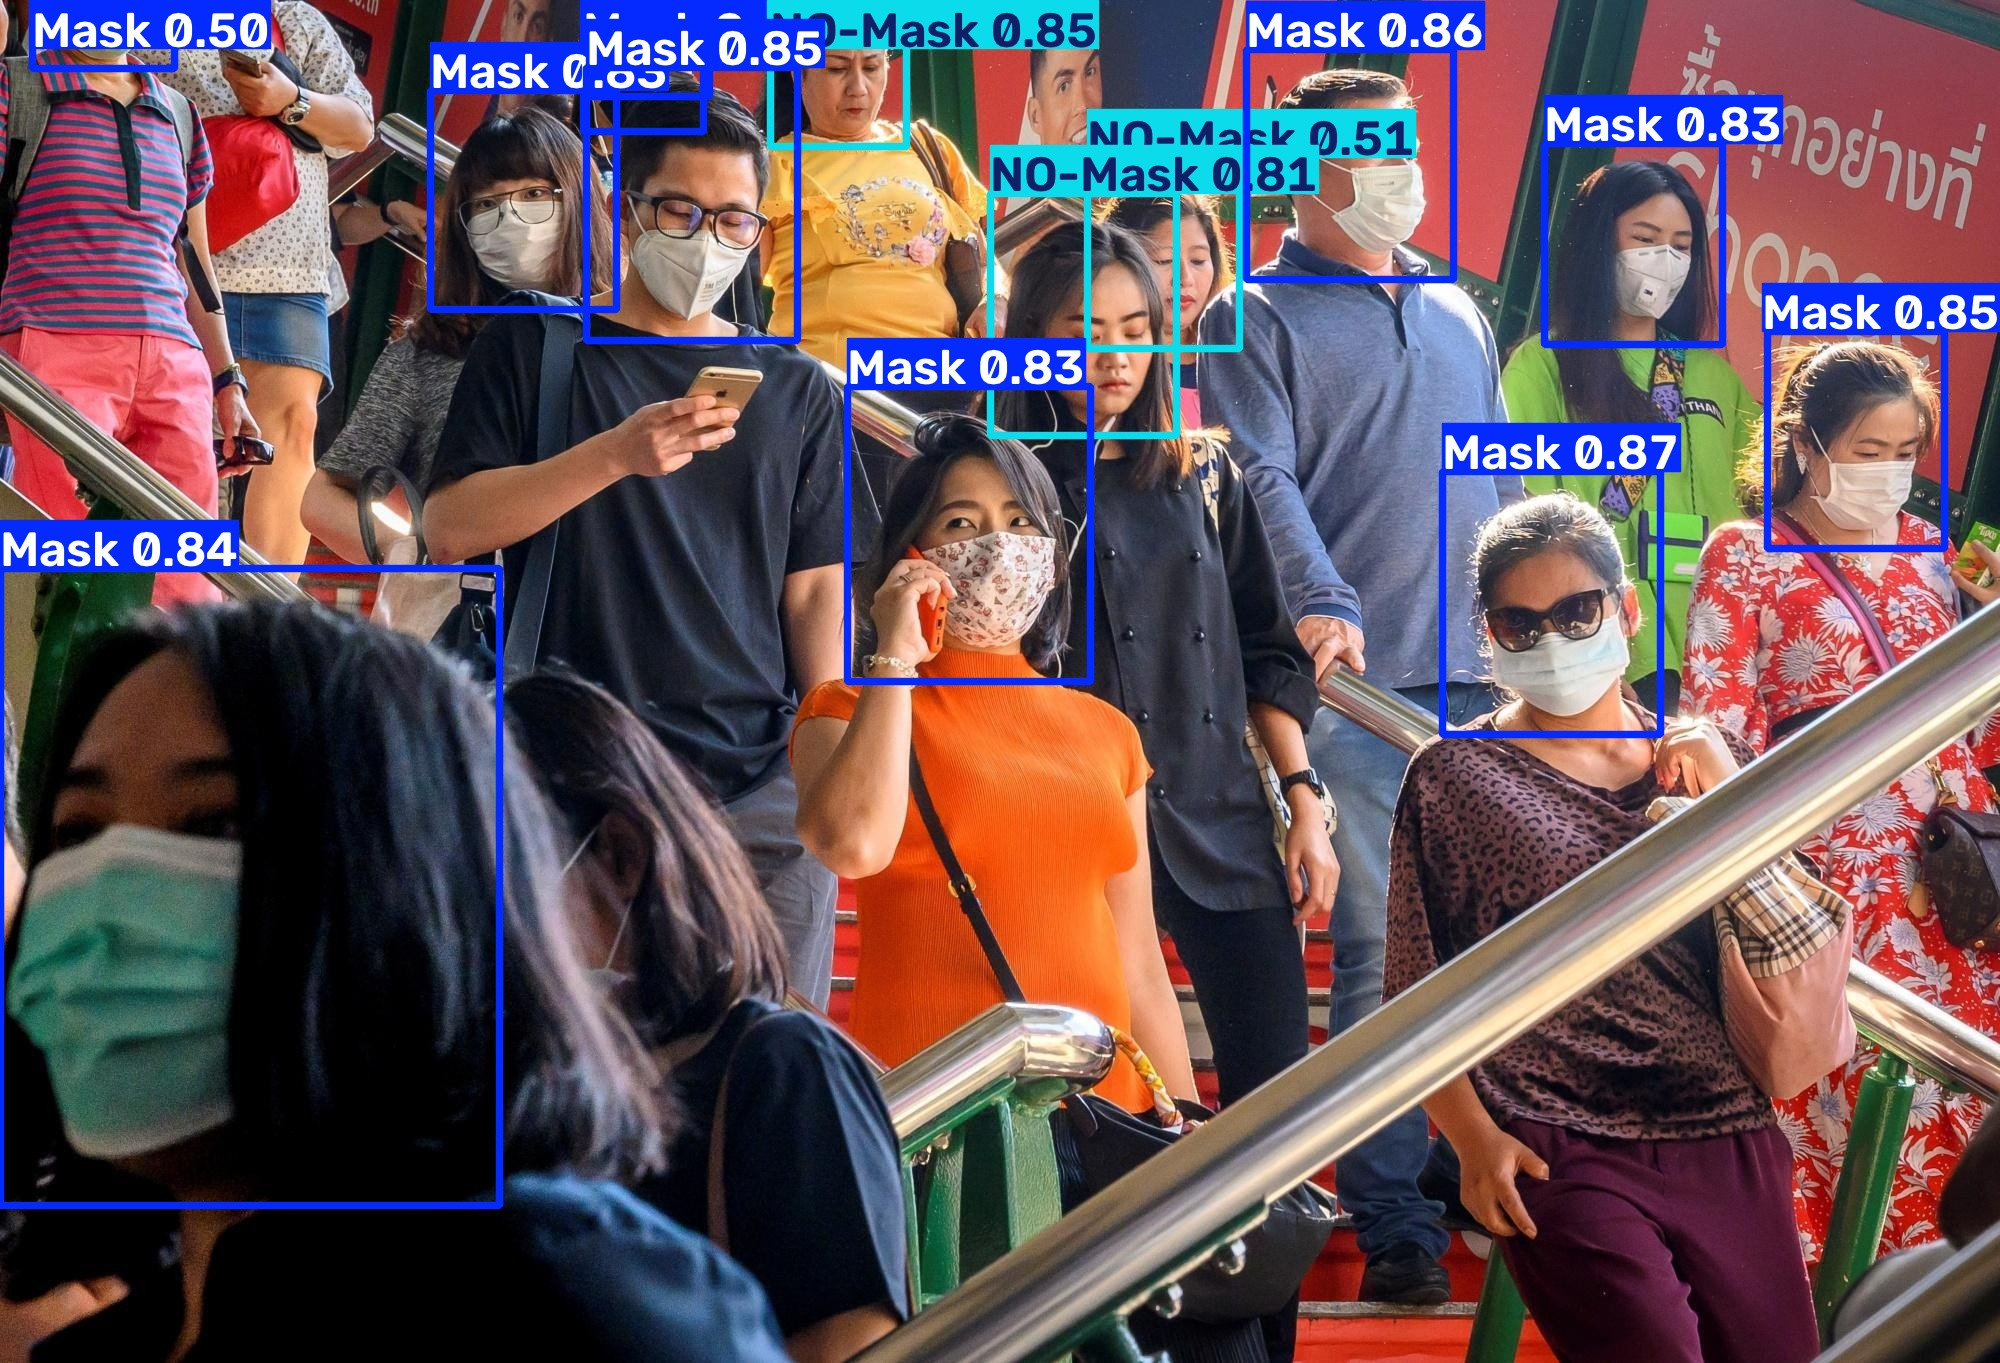

In [ ]:
import os
from IPython.display import Image, display

test_dir = f"{dataset_dir}/test/images"

# Predict directly on the folder (or pass a single image path)
predictions = model.predict(source=test_dir, conf=0.25, save=True)

# Grab the first processed image from YOLO's output
first_pred = predictions[0]
output_path = os.path.join(first_pred.save_dir, os.path.basename(first_pred.path))

print(f"Prediction saved at: {output_path}")
display(Image(filename=output_path))

In [ ]:
from google.colab import drive
import shutil

best_weights = "/content/runs/detect/ppe_yolo11_run/weights/best.pt"

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the destination folder in your Drive
drive_path = '/content/drive/MyDrive/YOLOv11_PPE_Project'
os.makedirs(drive_path, exist_ok=True)

# 3. Copy the best weights
shutil.copy(best_weights, f"{drive_path}/best.pt")

print(f"Model weights successfully backed up to: {drive_path}/best.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model weights successfully backed up to: /content/drive/MyDrive/YOLOv11_PPE_Project/best.pt
